# 2. Multi-scale analysis for Alzheimer’s disease dataset

In this notebook, we demonstrate how to use **SpatialZoomer** to identify multi-scale spatial structures in single-cell resolution spatial transcriptomics (ST) data, ranging from cells to niches and tissue domains.

For illustration, we use a Xenium v1 Alzheimer’s disease dataset containing **349,063 cells and 347 genes**. This dataset includes **six mouse brain samples**, including wild-type samples (**WT1, WT2, and WT3**) and TgCRND8 Alzheimer’s disease mouse model samples (**Tg1, Tg2, and Tg3**) collected at three time points, corresponding to mild, moderate, and advanced stages of amyloid-beta (Aβ) deposition.

The data integration and preprocessing steps have been completed in `1_Data_preparation_Xenium_V1_AD_Merged.ipynb`. **Users can either load the previously generated AnnData object or download the processed AnnData object from [Google Drive](https://drive.google.com/file/d/19iSZ3OHdBq2nldGF6OG5SaIeEblqRBXO/view?usp=drive_link).**

Information about the original raw data is available from the official 10x Genomics data release: [Xenium v1 Alzheimer’s disease dataset](https://www.10xgenomics.com/datasets/xenium-in-situ-analysis-of-alzheimers-disease-mouse-model-brain-coronal-sections-from-one-hemisphere-over-a-time-course-1-standard).

The notebook can be completed on a standard personal computer in approximately 30 minutes.

### 0. Load packages and data

Load the ST data, perform quality control on cells and genes, and apply normalization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Load packages
import spatialzoomer as sz
import numpy as np
import scanpy as sc
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Set figure parameters
plt.rcParams.update({
    "font.family":'sans-serif',
    "mathtext.fontset":'stix',
    "font.size": 7,
    'pdf.fonttype': 42,
    "figure.dpi": 80,      
    "savefig.dpi": 300      
    })
use_dpi = 80 

Please set the following basic information:
* `runLabel`: The name of dataset.

* `save_path`: A path to save the analysis results.

* `adata`: An **AnnData** object storing single-cell resolved spatial transcriptomics data,  

  - `adata.X` contains the transcriptomic signals.  
  
  - `adata.obsm['spatial']` stores the spatial coordinates.  
 
The **input ST data** in AnnData format can be downloaded from [Google Cloud](https://drive.google.com/file/d/1ITh3qNTEgnyqFh3BLXMvjTQxRsVsZkBC/view?usp=drive_link).

In [2]:
runLabel = 'Xenium_V1_AD_Merged'
save_path = 'E:/SpatialZoomer/Results/' + runLabel + "/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
adata = sc.read_h5ad(save_path + "/" + runLabel+ "_anndata.h5ad")
adata

AnnData object with n_obs × n_vars = 349063 × 347
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'Kmeans_Raw', 'leiden_Raw_res0.8', 'leiden_Raw_res1', 'Kmeans_scale0.01', 'leiden_scale0.01_res0.8', 'leiden_scale0.01_res1', 'Kmeans_scale1.1', 'leiden_scale1.1_res0.8', 'leiden_scale1.1_res1', 'Kmeans_scale3.0', 'leiden_scale3.0_res0.8', 'leiden_scale3.0_res1', 'Kmeans_scale4.5', 'leiden_scale4.5_res0.8', 'leiden_scale4.5_res1', 'Kmeans_scale6.0', 'leiden_scale6.0_res0.8', 'leiden_scale6.0_res1', 'Kmeans_scale8.0', 'leiden_scale8.0_res0.8', 'leiden_scale8.0_res1', 'Kmeans_scale10.5', 'leiden_scale10.5_res0.8', 'leiden_scale10.5

### 1. Extract multi-scale features via spectral graph signal processing

- Obtain **graph signals** (cell programs) from transcriptomic data using dimensionality reduction with **NMF**.  

- Construct a **spatial neighbor graph** based on the physical proximity of cells.  

- Apply a bank of **heat kernel–based low-pass filters** to extract features across multiple spatial scales.

Perform NMF to obtain graph signals:

`n_components` specifies the dimensionality of the graph signals.

For reproducibility, this notebook uses the precomputed NMF results stored in `adata.obsm["X_nmf"]`.

In [3]:
# adata = sz.performDR(adata, type = 'NMF', n_components=50)
# adata

Initialize the SpatialZoomer object and define a set of candidate scales.

In [4]:
sz_analyzer = sz.MultiscaleAnalysis(adata=adata, runLabel=runLabel, save_path=save_path)
 
scales = [0.01] \
    + np.arange(0.1, 2.1, 0.1).tolist() \
    + np.arange(2.5, 15.5, 0.5).tolist() \
    + np.arange(16, 21, 1).tolist() \
    +  np.arange(25, 55, 5).tolist()
scales = [round(x, 2) for x in scales]

In [5]:
sz_analyzer.dpi = use_dpi

Perform spectral graph signal processing to extract multi-scale features:

- `use_rep`: selects graph signals from adata.obsm; here we use "X_nmf" (NMF-transformed data)

- `n_neighbors`: number of neighbors in the spatial neighbor graph (recommended: 10–20)

- `scales`: custom-defined above; if not provided, scales are automatically generated as above

In [6]:
sz_analyzer.multiscale_transform(use_rep='X_nmf', n_neighbors=20, scales=scales)

Median similarities:  4.999999999984118
Time taken to construct spatial_knn: 2.7152 seconds
Time taken to perform spectral graph filter bank: 159.8199 seconds
Transformed signals saved to E:/SpatialZoomer/Results/Xenium_V1_AD_Merged/Xenium_V1_AD_Merged_transformed_signals.h5


### 2. Identify critical scales automatically

SpatialZoomer employs a dynamic programming strategy that partitions the cross-scale similarity map, which is constructed from transformed signals across ranked candidate scales, into contiguous diagonal blocks. The optimal number of blocks is determined automatically. From each block, the start and center points are selected as critical scales, representing “tipping” and “representative” points, respectively. 

- `max_clusters` and `min_clusters` specify the range of possible block numbers.  
  Within this range, the Elbow method is applied to automatically determine the optimal number of blocks.

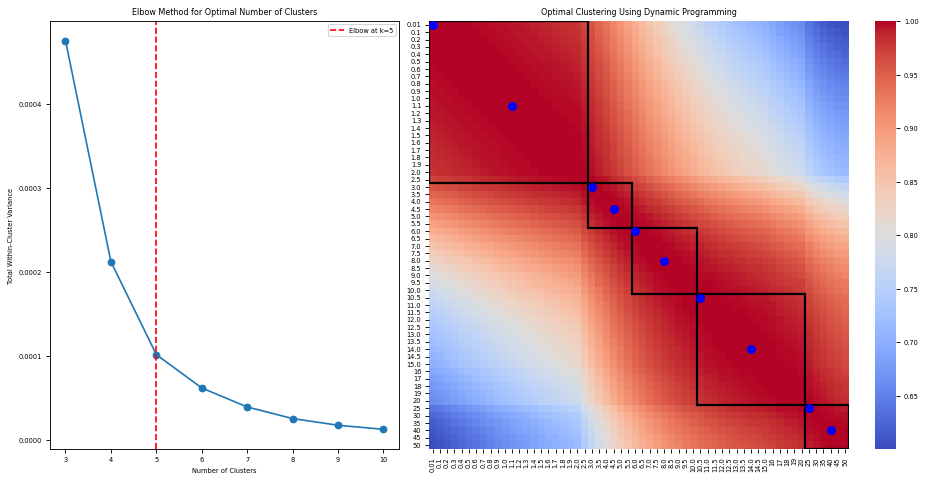

The optimal number of clusters is: 5
Typical scales: [0.01, 1.1, 3.0, 4.5, 6.0, 8.0, 10.5, 14.0, 25, 40]
Time taken to perform identification of typical scales: 16.3626 seconds


In [7]:
sz_analyzer.identify_typical_scales(max_clusters=10, min_clusters=3)

### 3. Identify spatial structures using two-step clustering

Clustering is performed in two steps:  

1. **Mini-Batch K-Means** is applied to the transformed signals at a given scale to obtain an initial coarse clustering, yielding 10,000 metacells.  

2. **Leiden algorithm** is then applied to the metacells to obtain fine-grained clusters. A higher clustering resolution yields more clusters.  

**Recommendation:** test **multiple resolution values** (e.g., 0.2, 0.4, 0.8, 1.0) and select the setting that matches biological expectations and downstream tasks.


In [8]:
resolutions = [0.8, 1]
sz_analyzer.clustering(n_clusters_kmeans=10000, resolutions=resolutions)

Time taken to perform UMAP and clustering for raw signal: 220.1451 seconds
Time taken to perform clustering for signal at scale 0.01: 107.9382 seconds
Time taken to perform clustering for signal at scale 1.1: 117.6753 seconds
Time taken to perform clustering for signal at scale 3.0: 109.2065 seconds
Time taken to perform clustering for signal at scale 4.5: 116.0103 seconds
Time taken to perform clustering for signal at scale 6.0: 110.2555 seconds
Time taken to perform clustering for signal at scale 8.0: 109.7700 seconds
Time taken to perform clustering for signal at scale 10.5: 110.0605 seconds
Time taken to perform clustering for signal at scale 14.0: 91.2984 seconds
Time taken to perform clustering for signal at scale 25.0: 96.1547 seconds
Time taken to perform clustering for signal at scale 40.0: 102.8200 seconds
Total time: 1071.4789 seconds


The clustering and UMAP results at each critical scale are stored in `sz_analyzer.adata`.

- **Clustering results** are stored in `sz_analyzer.adata.obs`, with keys formatted as `leiden_<scale>_res<resolution>`. 
  
  For example, "leiden_Raw_res0.8", "leiden_Raw_res1", "leiden_scale1.0_res0.8", and "leiden_scale1.0_res1".  


- **UMAP embeddings** are stored in `sz_analyzer.adata.obsm`, with keys formatted as `X_umap_<scale>`. 

  For example, "X_umap_Raw" and "X_umap_scale1.0".


In [9]:
sz_analyzer.adata

AnnData object with n_obs × n_vars = 349063 × 347
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'Kmeans_Raw', 'leiden_Raw_res0.8', 'leiden_Raw_res1', 'Kmeans_scale0.01', 'leiden_scale0.01_res0.8', 'leiden_scale0.01_res1', 'Kmeans_scale1.1', 'leiden_scale1.1_res0.8', 'leiden_scale1.1_res1', 'Kmeans_scale3.0', 'leiden_scale3.0_res0.8', 'leiden_scale3.0_res1', 'Kmeans_scale4.5', 'leiden_scale4.5_res0.8', 'leiden_scale4.5_res1', 'Kmeans_scale6.0', 'leiden_scale6.0_res0.8', 'leiden_scale6.0_res1', 'Kmeans_scale8.0', 'leiden_scale8.0_res0.8', 'leiden_scale8.0_res1', 'Kmeans_scale10.5', 'leiden_scale10.5_res0.8', 'leiden_scale10.5

### Results and Analysis

- In the **raw signal space** (Scale 0.0), clustering reflects the single-cell scale, enabling the identification of cell types or states.  

- **As the scale increases**, each cell progressively integrates spatial context from broader neighborhoods, resulting in smoother signals that capture more global spatial structures such as niches and domains.  

- **At excessively large scales** (e.g. scale 25.0 and 40.0), all cells become increasingly similar, and the signals are over-smoothed. In this regime, spatial smoothing overwhelms the omics heterogeneity, leading to block-like clusters on the spatial slide and spherical patterns in UMAP space that lack meaningful biological distinctions.

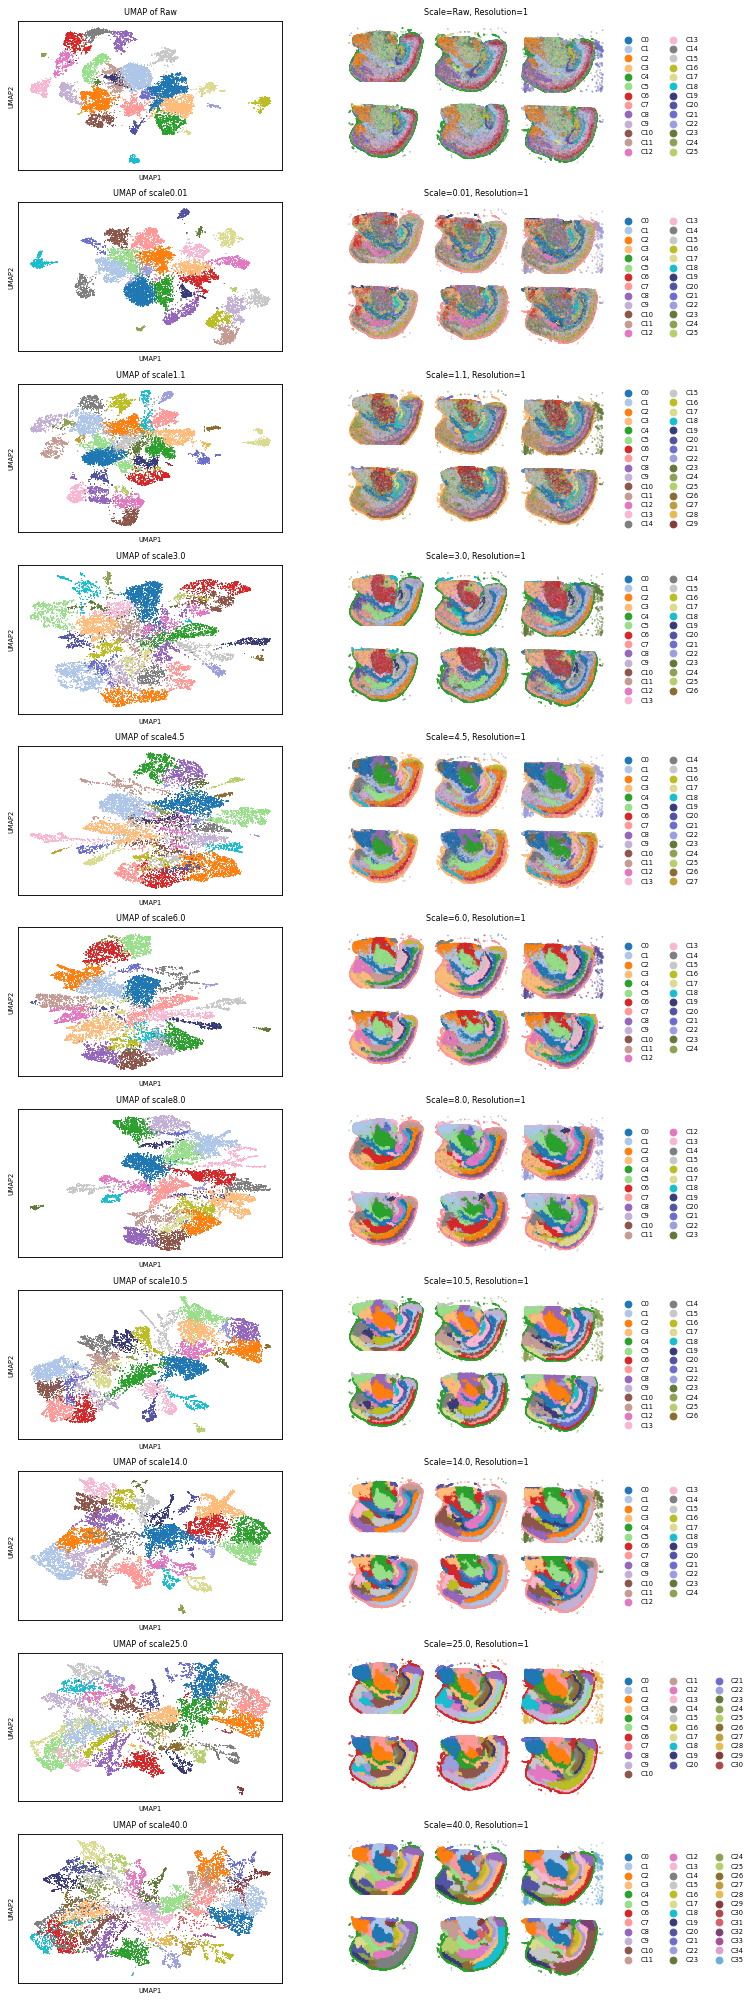

In [10]:
sz_analyzer.plot_multiscale_clusters(resolution=1, figsize=(10, 25), pt_size_umap= 1, pt_size_scatter= 0.1)

Quantify the contributions of spatial proximity and transcriptomic similarity to clustering outcomes across different scales.

Median similarities:  4.99999999346613
Time taken to construct expr_knn: 143.5127 seconds


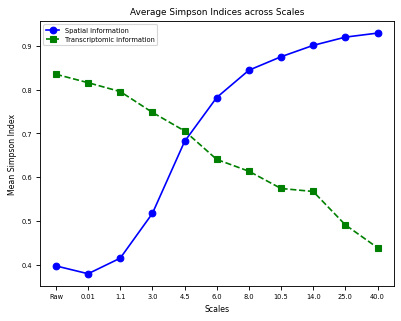

In [11]:
sz_analyzer.plot_simpson(resolution=1)

The `sz_analyzer.adata` object is an AnnData instance that is compatible with the Python ecosystem for scRNA-seq and ST data, including packages such as **scanpy** and **squidpy**. Users can therefore directly leverage these packages for further downstream analysis and visualization.

In [ ]:
sz_analyzer.adata.write(save_path + runLabel + '_anndata.h5ad')

### Results in `save_path` folder

The following output files are generated and saved in the `save_path` directory:

- `<runLabel>_transformed_signals.h5`: Stores the multi-scale features extracted by the spectral graph filter bank.  

  Dimensions: *cells × cell programs × candidate scales*.  

- `Typical_scales.pdf`: Visualization of critical scale selection, generated by `identify_typical_scales()`.  

- `Typical_scales.csv`: Data frame recording the selected critical scales.  

- `<runLabel>_object_kmeans_<critical scale>.h5ad`: A series of AnnData objects storing the K-Means clustering results of metacells at specific critical scales.

  These intermediate results can be further refined by applying the Leiden algorithm, where adjusting the clustering resolution allows generation of the final clustering results.

- `Average_Simpson_Indices_across_Scales.pdf`: Output of `plot_simpson()`, which quantifies the contributions of spatial proximity and transcriptomic similarity to clustering results across scales.  

- `<runLabel>_SpatialZoomer.h5ad`: The core AnnData object containing all multi-scale clustering results, recommended for downstream analyses.

### 4. Scale-to-distance mapping

After running SpatialZoomer, we can use sz.mapping_scale_to_distance() to quantify the **physical spatial range** each scale corresponds to.

The function builds a heat-kernel filter bank on the spatial KNN graph, samples seed cells with minimum-distance constraints, and aggregates their scale-filtered signals as a function of physical distance from the seed. The result is a heatmap showing how each scale diffuses spatially, broken down by cell density group (Low / Medium / High).

Results (PDFs, CSV tables, NPZ arrays) are saved in a scale_to_distance_mapping/ subfolder inside save_path.

Calculate density
Using percentile: 10 (q10=2.00, q90=8.00)
Density_group
Medium    237265
Low        64146
High       47652
Name: count, dtype: int64
Computing overall heatmap (all 2000 seeds)...
Computing heatmap for group Low (418 seeds)...
Computing heatmap for group Medium (1304 seeds)...
Computing heatmap for group High (278 seeds)...
[Saved] All group data -> E:/SpatialZoomer/Results/Xenium_V1_AD_Merged\scale_to_distance_mapping\heatmap_by_groups/H_matrix_All.csv, E95_distance_All.csv
[Saved] Low group data -> E:/SpatialZoomer/Results/Xenium_V1_AD_Merged\scale_to_distance_mapping\heatmap_by_groups/H_matrix_Low.csv, E95_distance_Low.csv
[Saved] Medium group data -> E:/SpatialZoomer/Results/Xenium_V1_AD_Merged\scale_to_distance_mapping\heatmap_by_groups/H_matrix_Medium.csv, E95_distance_Medium.csv
[Saved] High group data -> E:/SpatialZoomer/Results/Xenium_V1_AD_Merged\scale_to_distance_mapping\heatmap_by_groups/H_matrix_High.csv, E95_distance_High.csv
[Saved] PDF -> E:/SpatialZoom

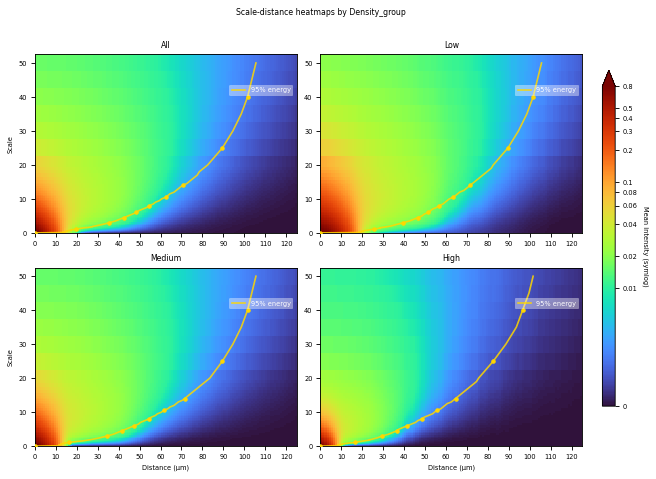

Time taken to perform physical distance analysis: 124.6913 seconds


In [13]:
# Run scale-to-distance mapping
# Uses sz_analyzer.adata which already contains spatial_knn (obsp) and
# X_umap_scale* embeddings (obsm) from the SpatialZoomer pipeline above.
out = sz.mapping_scale_to_distance(
    adata=sz_analyzer.adata,
    out_dir=save_path,
    run_label=runLabel,
    plot_sampling_rounds=False,          # number of rounds to run for sampling-based mapping
    typical_scales=None,        # auto-extract typical scales from obsm (X_umap_scale*)
    plot_typical_scales=True,   # mark typical scales on the heatmap
    normalize_rows=False,
    show=True,
    dpi=use_dpi,
    colorbar_vmax_symlog = 0.8
)